# Multimodal Embedding Alignment with LLaVA-1.6 + LoRA
### Authors: Francisco Nicolás Noya and Pablo Gómez

### A Proof-of-Concept Inspired by VLM2Vec 


---

This notebook demonstrates **multimodal embedding alignment**: we fine-tune a large vision-language model so that the text embedding of *"The number 8"* ends up close to the image embedding of the digit `8` in MNIST space — and far from all other digits.

**Core idea from VLM2Vec:** a frozen (or lightly adapted) VLM can be repurposed as a universal multimodal *embedding* model by treating the last-token hidden state as a dense representation. We use the same LLaVA backbone as a **dual encoder**:
- One forward pass sees **text only** → text embedding  
- Another forward pass sees **image only** → image embedding  

These two embeddings are then aligned via a **diagonal InfoNCE (contrastive) loss**.

**What we cover:**
1. Sampling representative MNIST images (one per digit class)  
2. Loading LLaVA-1.6 in `bfloat16` and wrapping it with LoRA adapters  
3. Formatting text-only and image-only prompts using the LLaVA chat template  
4. Extracting last-token embeddings and L2-normalising them  
5. Computing the diagonal InfoNCE loss and back-propagating through LoRA parameters  
6. Training for 50 steps and evaluating the 10×10 digit similarity matrix

## 1 · Install & Import Dependencies

We need:
- `transformers` ≥ 4.40 for LLaVA-Next support  
- `peft` for LoRA  
- `torchvision` for MNIST  
- `Pillow` for image handling  
- Standard scientific stack: `torch`, `numpy`, `matplotlib`

In [12]:
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

pip_install(
    "transformers>=4.40.0",
    "peft>=0.10.0",
    "torchvision",
    "Pillow",
    "accelerate",
    "bitsandbytes>=0.43.0",   # 4-bit NF4 quantisation for T4 / 16 GB GPUs
)

print("All packages installed.")

All packages installed.


In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# HuggingFace
from transformers import (
    LlavaNextProcessor,
    LlavaNextForConditionalGeneration,
    BitsAndBytesConfig,          # 4-bit quantisation config
)

# PEFT / LoRA
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# MNIST
import torchvision
import torchvision.transforms as T

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
COMPUTE_DTYPE = torch.bfloat16

print(f"Running on: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Running on: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 2 · Load MNIST and Sample Representative Images

We grab the MNIST training set and pick **one image per digit class** (0–9). These 10 PIL images form our *image corpus* — small enough to hold entirely in GPU memory during training.

> **Why PIL?** The LLaVA processor expects `PIL.Image` objects for its vision preprocessing pipeline.

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.11MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.6MB/s]


Digit labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


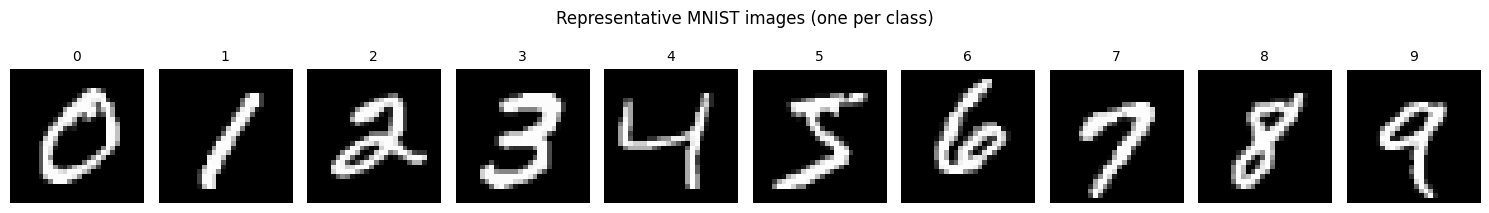

In [14]:
# Download MNIST (cached after first run)
mnist_train = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=T.ToTensor()
)

# Pick one representative image per digit class
repr_images: list[Image.Image] = []   # 10 PIL images
repr_labels: list[int] = []           # matching integer labels 0–9

found = {d: False for d in range(10)}
for img_tensor, label in mnist_train:
    if not found[label]:
        # Convert greyscale tensor → RGB PIL (LLaVA expects RGB)
        arr = (img_tensor.squeeze().numpy() * 255).astype(np.uint8)
        pil_img = Image.fromarray(arr).convert("RGB")
        repr_images.append(pil_img)
        repr_labels.append(label)
        found[label] = True
    if all(found.values()):
        break

# Sort by label so index == digit value
paired = sorted(zip(repr_labels, repr_images), key=lambda x: x[0])
repr_labels = [p[0] for p in paired]
repr_images = [p[1] for p in paired]

print("Digit labels:", repr_labels)

# Quick visual check
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for ax, img, lbl in zip(axes, repr_images, repr_labels):
    ax.imshow(img, cmap="gray")
    ax.set_title(str(lbl), fontsize=10)
    ax.axis("off")
plt.suptitle("Representative MNIST images (one per class)", y=1.05)
plt.tight_layout()
plt.show()

## 3 · Load LLaVA-1.6 Model and Processor

A full `llava-v1.6-mistral-7b-hf` in float16 would occupy ~14 GB — too much for a T4's 16 GB once you add activations and LoRA gradients. We apply **4-bit NF4 quantisation** via `bitsandbytes`, which compresses the base weights to ~4 GB:

| Precision | Model VRAM |
|-----------|-----------|
| bfloat16 (base) | ~14 GB |
| 4-bit NF4 + bf16 compute | ~4 GB ✅ |

Key `BitsAndBytesConfig` choices:
- `load_in_4bit=True` — quantise weights to 4-bit NF4  
- `bnb_4bit_compute_dtype=torch.bfloat16` — activations in bfloat16 (better dynamic range and stability than float16)  
- `bnb_4bit_use_double_quant=True` — nested quantisation saves another ~0.4 GB  
- `bnb_4bit_quant_type="nf4"` — Normal Float 4, optimal for normally-distributed weights  

After loading, `prepare_model_for_kbit_training()` enables gradient checkpointing and casts the `LayerNorm` and embedding layers to fp16 so that LoRA gradients flow correctly through the frozen 4-bit base.

In [15]:
!nvidia-smi

Sun Mar  8 16:14:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [16]:
MODEL_ID = "llava-hf/llava-v1.6-mistral-7b-hf"

# ── 4-bit NF4 quantisation config ───────────────────────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,   # fp16 compute on T4
    bnb_4bit_use_double_quant=True,         # nested quantisation → saves ~0.4 GB
    bnb_4bit_quant_type="nf4",              # NormalFloat4 for normally-distributed weights
)

print(f"Loading processor from {MODEL_ID} ...")
processor = LlavaNextProcessor.from_pretrained(MODEL_ID)

print(f"Loading model from {MODEL_ID} in 4-bit NF4 ...")
model = LlavaNextForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",          # fits the quantised model on a single T4
    low_cpu_mem_usage=True,
)

print("Model loaded.")
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1e9
    reserved  = torch.cuda.memory_reserved()  / 1e9
    print(f"GPU memory — allocated: {allocated:.1f} GB | reserved: {reserved:.1f} GB")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B")

Loading processor from llava-hf/llava-v1.6-mistral-7b-hf ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


processor_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded.
GPU memory — allocated: 4.3 GB | reserved: 13.5 GB
Total parameters: 3.92B


## 4 · Apply LoRA to the Full Model (LLM Backbone + Vision Encoder)

**LoRA (Low-Rank Adaptation)** injects a pair of low-rank matrices $A \in \mathbb{R}^{r \times d}$ and $B \in \mathbb{R}^{d \times r}$ alongside each frozen weight $W_0$:

$$W = W_0 + \frac{\alpha}{r} \cdot BA$$

We use two steps:

1. **`prepare_model_for_kbit_training`** — mandatory when combining LoRA with 4-bit quantisation. It:
   - Enables gradient checkpointing (trades compute for activation memory)
   - Upcasts `LayerNorm` and embedding layers to fp16 so gradients are numerically stable

2. **`get_peft_model`** with `LoraConfig`:
   - `r = 8` (rank, controls capacity)
   - `lora_alpha = 16` (scale = α/r = 2)
   - `target_modules = "all-linear"` — hooks every `nn.Linear` in both the CLIP vision encoder and the Mistral LLM backbone

The base weights remain frozen in 4-bit; only the ~1% LoRA adapter floats are updated.

In [17]:
# ── Step 1: prepare the quantised model for LoRA training ───────────────────
# This enables gradient checkpointing and casts LayerNorm / embeddings to fp16
# so that LoRA adapter gradients flow correctly through the 4-bit frozen base.
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

# ── Step 2: inject LoRA adapters ─────────────────────────────────────────────
lora_config = LoraConfig(
    r=8,                          # low-rank dimension
    lora_alpha=16,                # scaling factor α
    target_modules="all-linear",  # hook every nn.Linear in the full model
    lora_dropout=0.05,
    bias="none",
    task_type=None,               # not a standard HF seq2seq / causal-LM task
)

model = get_peft_model(model, lora_config)
model.train()
model.print_trainable_parameters()

trainable params: 24,616,960 || all params: 7,591,364,608 || trainable%: 0.3243


## 5 · Define Text and Image Prompt Formatting

LLaVA-1.6 uses a **chat template** that must be applied consistently. The two modalities require different prompt structures:

| Modality | Prompt content | `<image>` token? |
|----------|---------------|-----------------|
| **Text only** | `"The number N"` | ❌ No |
| **Image only** | `"What is shown in this image?"` | ✅ Yes |

**Text prompt:** We use the Mistral instruction template `[INST] ... [/INST]` without any `<image>` placeholder. The model sees only the digit description and produces a text embedding.

**Image prompt:** We include the `<image>` token so the processor replaces it with the projected vision features. The text part gives a generic, digit-agnostic instruction — the digit identity must come from the image only, never from the text.

In [18]:
def format_text_prompt(digit: int) -> dict:
    """
    Build tokenised inputs for a text-only LLaVA prompt.
    Uses the Mistral [INST] chat template without any <image> token.

    Args:
        digit: integer 0-9

    Returns:
        dict with 'input_ids' and 'attention_mask' on DEVICE
    """
    description = f"The number {digit}"
    # Apply the chat template: [INST] <description> [/INST]
    conversation = [
        {"role": "user", "content": description},
    ]
    text = processor.tokenizer.apply_chat_template(
        conversation,
        tokenize=False,
        add_generation_prompt=True,   # adds trailing [/INST] so the model "stops"
    )
    inputs = processor.tokenizer(
        text,
        return_tensors="pt",
    )
    return {k: v.to(DEVICE) for k, v in inputs.items()}


def format_image_prompt(pil_image: Image.Image) -> dict:
    """
    Build tokenised inputs for an image-only LLaVA prompt.
    The text is a generic, digit-agnostic question; digit identity
    must come from the pixel values alone.

    Args:
        pil_image: PIL.Image (RGB)

    Returns:
        dict with 'input_ids', 'attention_mask', 'pixel_values' on DEVICE
    """
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "image"},                          # <image> placeholder
                {"type": "text", "text": "Describe this image briefly."},
            ],
        }
    ]
    text = processor.apply_chat_template(
        conversation,
        add_generation_prompt=True,
    )
    inputs = processor(
        text=text,
        images=pil_image,
        return_tensors="pt",
    )
    return {k: v.to(DEVICE) for k, v in inputs.items()}


# ── Sanity check ─────────────────────────────────────────────────────────────
txt_inputs = format_text_prompt(5)
img_inputs = format_image_prompt(repr_images[5])

print("Text input_ids shape :", txt_inputs["input_ids"].shape)
print("Image input_ids shape:", img_inputs["input_ids"].shape)
print("Image pixel_values shape:", img_inputs["pixel_values"].shape)

Text input_ids shape : torch.Size([1, 13])
Image input_ids shape: torch.Size([1, 1192])
Image pixel_values shape: torch.Size([1, 3, 3, 336, 336])


## 6 · Define Embedding Extraction Function

**How we get a fixed-size embedding from a generative decoder:**

VLM2Vec's key insight is to treat the **last token's hidden state** as a dense sentence (or image) embedding. For a sequence of length $T$:

$$\mathbf{e} = \text{LLM}(x_{1:T})[-1, :]$$

This works because the final token has attended to every previous token (causal attention), so it summarises the full input context. After extraction we **L2-normalise** so that dot products equal cosine similarities, which is required for the InfoNCE loss.

> **Implementation note:** We call the model with `output_hidden_states=True` to access the last layer's hidden states before the LM head projection.

In [19]:
def get_embedding(inputs: dict) -> torch.Tensor:
    """
    Run a forward pass and return the L2-normalised last-token hidden state.

    The function works for both text-only inputs (no pixel_values key) and
    image+text inputs (with pixel_values), because LlavaNextForConditionalGeneration
    handles both cases gracefully.

    Args:
        inputs: dict returned by format_text_prompt or format_image_prompt

    Returns:
        Tensor of shape (hidden_size,) in float32, L2-normalised
    """
    outputs = model(
        **inputs,
        output_hidden_states=True,
        return_dict=True,
    )
    # hidden_states is a tuple of (n_layers + 1) tensors, each (1, seq_len, hidden)
    last_hidden = outputs.hidden_states[-1]          # (1, T, H)
    # Take the final token position — detach everything else immediately
    emb = last_hidden[0, -1, :].clone()              # (H,) — clone before del
    # Free all other forward-pass buffers (logits, past_key_values, etc.)
    # keeping only the grad_fn chain attached to `emb` itself.
    del outputs, last_hidden
    # Cast to float32 for numerically stable normalisation
    emb = emb.float()
    emb = emb / (emb.norm() + 1e-8)                 # L2 normalise
    return emb


# ── Sanity check ─────────────────────────────────────────────────────────────
with torch.no_grad():
    e_txt = get_embedding(format_text_prompt(3))
    e_img = get_embedding(format_image_prompt(repr_images[3]))


print("Text embedding shape:", e_txt.shape)
print("Text embedding norm (should be ≈1):", e_txt.norm().item())
print("Image embedding shape:", e_img.shape)

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


Text embedding shape: torch.Size([4096])
Text embedding norm (should be ≈1): 1.0
Image embedding shape: torch.Size([4096])


## 7 · Diagonal InfoNCE Loss

The **InfoNCE** (Noise-Contrastive Estimation) loss, popularised by CLIP, treats each sample in the batch as a positive for exactly one other sample and a negative for all others.

Given:
- $Q \in \mathbb{R}^{N \times d}$ — batch of L2-normalised **text** embeddings  
- $K \in \mathbb{R}^{N \times d}$ — batch of L2-normalised **image** embeddings  
- $\tau$ — temperature hyperparameter (`0.07` by default)

The $N \times N$ similarity matrix is:

$$S = Q K^\top / \tau$$

Since pair $(q_i, k_i)$ corresponds to the **same digit**, the positive is always on the diagonal. The loss is the average of two symmetric cross-entropy terms:

$$\mathcal{L} = \frac{1}{2}\left(\text{CE}(S,\ \mathbf{I}_N) + \text{CE}(S^\top,\ \mathbf{I}_N)\right)$$

- Row-wise CE (`text → image`): for each text query $q_i$, predict which image $k_j$ is the match  
- Column-wise CE (`image → text`): for each image $k_j$, predict which text $q_i$ is the match

At random initialisation this loss equals $\log N \approx 2.30$ for $N=10$. As training progresses the diagonal values should increase and the loss should decrease.

In [20]:
import torch.nn.functional as F

def infonce_loss(
    q: torch.Tensor,
    k: torch.Tensor,
    temperature: float = 0.07,
) -> torch.Tensor:
    """
    Symmetric diagonal InfoNCE (CLIP-style) loss.

    Args:
        q: (N, d) L2-normalised text embeddings
        k: (N, d) L2-normalised image embeddings
        temperature: softmax temperature τ

    Returns:
        Scalar loss tensor (differentiable)
    """
    N = q.shape[0]

    # N×N cosine similarity matrix (already L2-normed, so dot = cosine)
    logits = q @ k.T / temperature          # (N, N)

    # Target: index i should match column i (diagonal positives)
    targets = torch.arange(N, device=q.device)

    # Symmetric cross-entropy
    loss_t2i = F.cross_entropy(logits,   targets)   # text  → image
    loss_i2t = F.cross_entropy(logits.T, targets)   # image → text

    return (loss_t2i + loss_i2t) / 2.0


# ── Sanity check: random embeddings → loss ≈ log(N) ─────────────────────────
N = 10
q_rand = F.normalize(torch.randn(N, 4096), dim=-1)
k_rand = F.normalize(torch.randn(N, 4096), dim=-1)
loss_rand = infonce_loss(q_rand, k_rand)
print(f"Random loss: {loss_rand.item():.4f}  (expected ≈ log(10) = {np.log(N):.4f})")

Random loss: 2.3322  (expected ≈ log(10) = 2.3026)


## 8 · Training Loop (5 Steps)

Each training step:

1. **Sample** `BATCH_SIZE=4` digit indices at random  
2. **Encode** those 4 text descriptions → $Q \in \mathbb{R}^{4 \times d}$ (using pre-tokenised inputs)
3. **Augment & encode** those 4 digit images → $K \in \mathbb{R}^{4 \times d}$ (fresh random transform each step)
4. Compute **InfoNCE loss** (positives still on the diagonal) and call `loss.backward()`  
5. **AdamW** step on LoRA parameters only; then `torch.cuda.empty_cache()`

**Why mini-batching?** Each `get_embedding()` call keeps a computation graph pinned in GPU memory until `backward()` runs. Encoding all 10 pairs simultaneously holds 20 graphs at once (~OOM on T4). Reducing to 4 pairs limits live graphs to **8**, cutting peak activation memory by ~2.5×.

**Why per-step image augmentation?** The processor inputs for images are **not** pre-computed — `format_image_prompt` is called fresh inside the loop after applying a random `T.RandomAffine + T.ColorJitter + T.GaussianBlur` transform. This means the model sees a slightly different version of each digit image at every step, acting as regularisation and preventing the model from memorising pixel-level artifacts rather than digit identity. Horizontal flips are excluded to preserve digit shapes (6 ≠ 9).

In [21]:
!nvidia-smi

Sun Mar  8 16:21:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P0             35W /   70W |   13573MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Baseline: Pre-Training Similarity Matrix (No Fine-Tuning)

Before updating any weights, we evaluate the **raw LLaVA embeddings** on the same 10×10 retrieval task. This gives us a baseline to compare against after training — if the diagonal is already dominant here, the task is trivial; if it's close to random, learning is required.

Pre-processing text and image inputs ...
Done.
[BASELINE]  Recall@1 = Precision@1 = 10%  (1/10 correct)


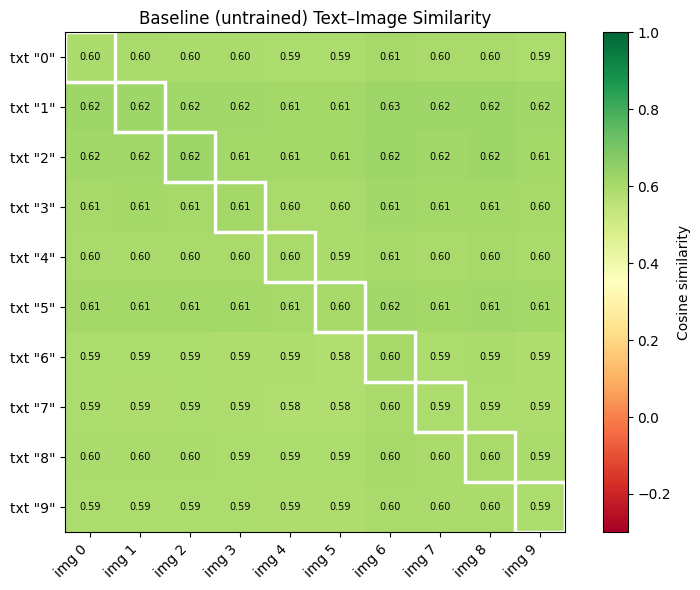

In [22]:
# Pre-compute inputs once for baseline eval (reused in training too)
print("Pre-processing text and image inputs ...")
all_text_inputs  = [format_text_prompt(d)   for d in range(10)]
all_image_inputs = [format_image_prompt(img) for img in repr_images]
print("Done.")

# ── Baseline eval with untrained LoRA (weights initialised to zero) ───────────
model.eval()
with torch.no_grad():
    Q_base = torch.stack([get_embedding(t) for t in all_text_inputs])   # (10, H)
    K_base = torch.stack([get_embedding(i) for i in all_image_inputs])  # (10, H)

sim_base = (Q_base @ K_base.T).cpu().float().numpy()   # (10, 10)

top1_base   = sim_base.argmax(axis=1)
recall_base = (top1_base == np.arange(10)).mean()
p1_base     = recall_base   # P@1 == R@1 for single-positive retrieval
print(f"[BASELINE]  Recall@1 = Precision@1 = {recall_base*100:.0f}%  ({int(recall_base*10)}/10 correct)")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sim_base, cmap="RdYlGn", vmin=-0.3, vmax=1.0)
plt.colorbar(im, ax=ax, label="Cosine similarity")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels([f"img {d}" for d in range(10)], rotation=45, ha="right")
ax.set_yticklabels([f"txt \"{d}\"" for d in range(10)])
ax.set_title("Baseline (untrained) Text–Image Similarity")
for i in range(10):
    ax.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, edgecolor="white", linewidth=2.5))
for i in range(10):
    for j in range(10):
        ax.text(j, i, f"{sim_base[i,j]:.2f}", ha="center", va="center", fontsize=7,
                color="black" if 0.1 < sim_base[i,j] < 0.8 else "white")
plt.tight_layout()
plt.show()


  Step      Loss  (batch=4, augmented images)
------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


     1    1.3639

Training complete.


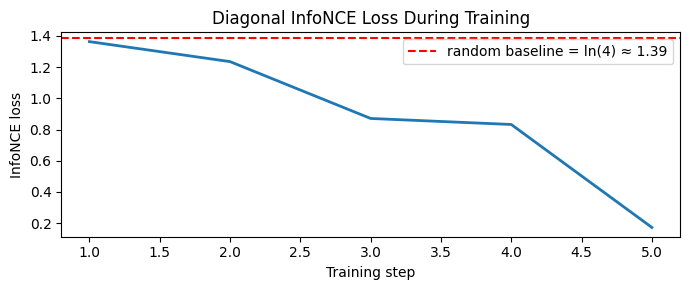

In [ ]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
NUM_STEPS   = 5
LR          = 2e-4
TEMPERATURE = 0.07
LOG_EVERY   = 1
BATCH_SIZE  = 4   # simultaneous computation graphs = 2 * BATCH_SIZE

# ── Image augmentation applied fresh at every training step ──────────────────
# Each step a randomly-perturbed version of the digit image is encoded, so the
# model never sees the exact same pixel values twice — acting as light
# regularisation.  NO horizontal flip: it would corrupt digits like 6/9.
train_aug = T.Compose([
    T.RandomAffine(degrees=12, translate=(0.08, 0.08), scale=(0.88, 1.12)),
    T.ColorJitter(brightness=0.3, contrast=0.3),
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
])

def augment_pil(pil_img: Image.Image) -> Image.Image:
    """Apply random spatial + photometric augmentations to a PIL image."""
    return train_aug(pil_img)

# ── Optimiser — only LoRA parameters ────────────────────────────────────────
lora_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(lora_params, lr=LR, weight_decay=1e-2)

# ── Training ─────────────────────────────────────────────────────────────────
model.train()
loss_history = []
rng = np.random.default_rng(SEED)

print(f"\n{'Step':>6}  {'Loss':>8}  (batch={BATCH_SIZE}, augmented images)")
print("-" * 48)

for step in range(1, NUM_STEPS + 1):
    optimizer.zero_grad()

    # Sample BATCH_SIZE digit indices (without replacement) for this step
    indices = rng.choice(10, size=BATCH_SIZE, replace=False).tolist()

    # --- Text encodings (pre-tokenised, reused from baseline cell) ---
    q_list = []
    for idx in indices:
        emb = get_embedding(all_text_inputs[idx])
        q_list.append(emb)
    Q = torch.stack(q_list)   # (B, H)

    # --- Image encodings with fresh augmentation each step ---------------
    # format_image_prompt is called here (not pre-computed) so every step
    # the model sees a newly-augmented version of each selected digit image.
    k_list = []
    for idx in indices:
        aug_img  = augment_pil(repr_images[idx])          # new random transform
        i_inputs = format_image_prompt(aug_img)           # encode on the fly
        emb      = get_embedding(i_inputs)
        k_list.append(emb)
    K = torch.stack(k_list)   # (B, H)

    # --- InfoNCE loss ---
    loss = infonce_loss(Q, K, temperature=TEMPERATURE)

    # --- Backward + update ---
    loss.backward()
    torch.nn.utils.clip_grad_norm_(lora_params, max_norm=1.0)
    optimizer.step()
    torch.cuda.empty_cache()

    loss_val = loss.item()
    loss_history.append(loss_val)

    if step % LOG_EVERY == 0 or step == 1:
        print(f"{step:>6}  {loss_val:>8.4f}")

print("\nTraining complete.")

# ── Plot loss curve ───────────────────────────────────────────────────────────
plt.figure(figsize=(7, 3))
plt.plot(range(1, NUM_STEPS + 1), loss_history, linewidth=2)
plt.axhline(y=np.log(BATCH_SIZE), color="red", linestyle="--",
            label=f"random baseline = ln({BATCH_SIZE}) ≈ {np.log(BATCH_SIZE):.2f}")
plt.xlabel("Training step")
plt.ylabel("InfoNCE loss")
plt.title("Diagonal InfoNCE Loss During Training")
plt.legend()
plt.tight_layout()
plt.show()

## 9 · Evaluation: 10 × 10 Similarity Matrix

We re-encode all 10 text queries and all 10 images under `torch.no_grad()` and compute the full pairwise cosine similarity matrix:

$$S_{ij} = q_i \cdot k_j \quad \in [-1,\ 1]$$

If training succeeded, the **diagonal** $S_{ii}$ should be the maximum in each row.

**Metrics reported** (for single-positive closed-set retrieval, both are identical but shown explicitly):
- **Recall@1** — fraction of text queries whose top-1 retrieved image is the correct digit  
- **Precision@1** — fraction of top-1 retrieved images that are correct (equals R@1 here since each query has exactly one positive)

We also show a **side-by-side heatmap** vs the untrained baseline from the previous cell to make the improvement visually clear.

[BASELINE]       Recall@1 = Precision@1 = 10%  (1/10)
[AFTER TRAINING] Recall@1 = Precision@1 = 100%  (10/10)
Δ improvement: +90 pp

10×10 Cosine Similarity Matrix  (rows = text queries, cols = image keys)
Diagonal entries should be the row-wise maxima:

         0    1    2    3    4    5    6    7    8    9
  -----------------------------------------------------
  0  | [+0.48]   +0.34    +0.34    +0.33    +0.26    +0.29    +0.26    +0.30    +0.33    +0.32 
  1  |  +0.41   [+0.55]   +0.34    +0.38    +0.35    +0.33    +0.27    +0.32    +0.34    +0.35 
  2  |  +0.45    +0.42   [+0.75]   +0.45    +0.45    +0.40    +0.46    +0.56    +0.51    +0.51 
  3  |  +0.39    +0.37    +0.39   [+0.75]   +0.37    +0.37    +0.42    +0.36    +0.40    +0.43 
  4  |  +0.41    +0.37    +0.43    +0.36   [+0.80]   +0.33    +0.39    +0.37    +0.45    +0.44 
  5  |  +0.37    +0.39    +0.40    +0.47    +0.34   [+0.78]   +0.35    +0.40    +0.39    +0.44 
  6  |  +0.33    +0.28    +0.39    +0.38    +0.35    +0.3

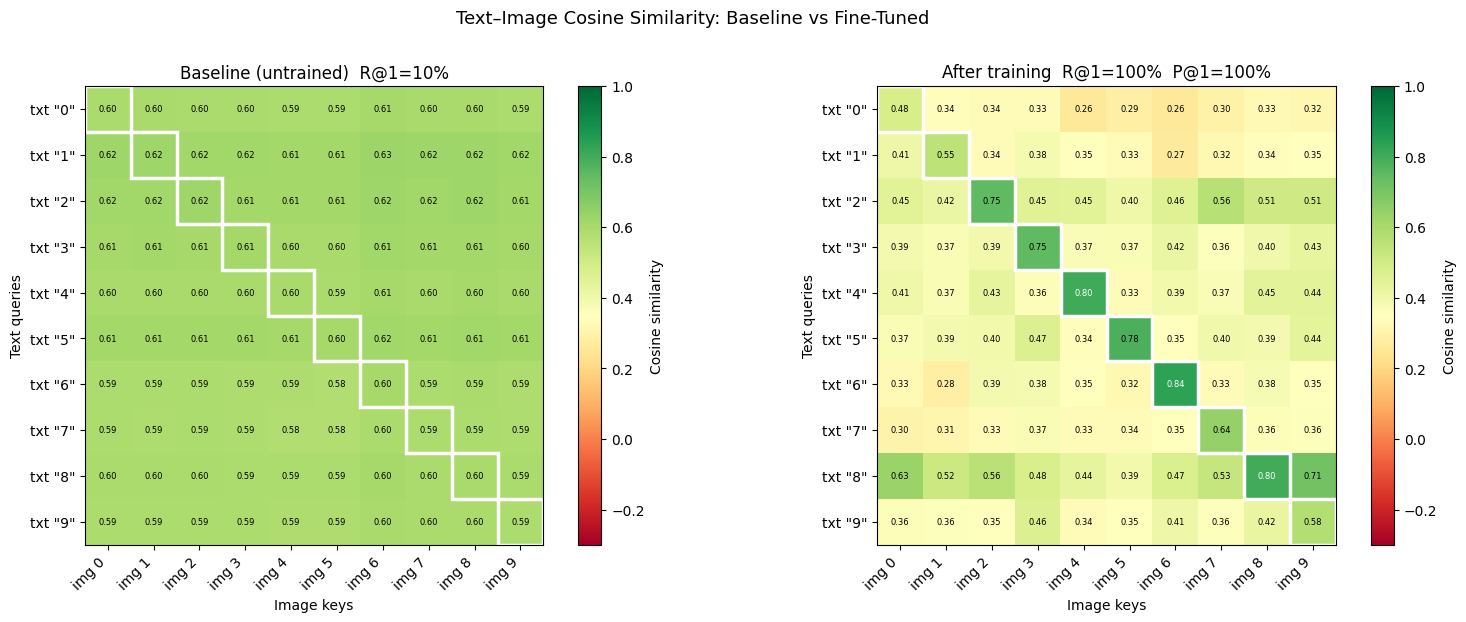

In [24]:
model.eval()

with torch.no_grad():
    Q_eval = torch.stack([get_embedding(t) for t in all_text_inputs])   # (10, H)
    K_eval = torch.stack([get_embedding(i) for i in all_image_inputs])  # (10, H)

sim_matrix = (Q_eval @ K_eval.T).cpu().float().numpy()   # (10, 10)

# ── Metrics ───────────────────────────────────────────────────────────────────
# For single-positive closed-set retrieval, Precision@1 == Recall@1.
# We compute both explicitly for clarity and report the delta vs baseline.
top1_preds    = sim_matrix.argmax(axis=1)
correct_mask  = (top1_preds == np.arange(10))
recall_at_1   = correct_mask.mean()
precision_at_1 = correct_mask.mean()   # P@1 = TP / (TP+FP); with k=1, equals R@1

print(f"[BASELINE]       Recall@1 = Precision@1 = {recall_base*100:.0f}%  ({int(recall_base*10)}/10)")
print(f"[AFTER TRAINING] Recall@1 = Precision@1 = {recall_at_1*100:.0f}%  ({int(recall_at_1*10)}/10)")
print(f"Δ improvement: +{(recall_at_1 - recall_base)*100:.0f} pp\n")

# ── Print similarity matrix ───────────────────────────────────────────────────
print("10×10 Cosine Similarity Matrix  (rows = text queries, cols = image keys)")
print("Diagonal entries should be the row-wise maxima:\n")
header = "       " + "  ".join(f"  {d}" for d in range(10))
print(header)
print("  " + "-" * (len(header) - 2))
for i, row in enumerate(sim_matrix):
    row_str = "  ".join(
        f"[{v:+.2f}]" if j == i else f" {v:+.2f} " for j, v in enumerate(row)
    )
    print(f"  {i}  | {row_str}")

# ── Side-by-side heatmaps: baseline vs fine-tuned ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labels_x = [f"img {d}" for d in range(10)]
labels_y = [f"txt \"{d}\"" for d in range(10)]

for ax, mat, title in zip(
    axes,
    [sim_base, sim_matrix],
    [f"Baseline (untrained)  R@1={recall_base*100:.0f}%",
     f"After training  R@1={recall_at_1*100:.0f}%  P@1={precision_at_1*100:.0f}%"],
):
    im = ax.imshow(mat, cmap="RdYlGn", vmin=-0.3, vmax=1.0)
    plt.colorbar(im, ax=ax, label="Cosine similarity")
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_xticklabels(labels_x, rotation=45, ha="right")
    ax.set_yticklabels(labels_y)
    ax.set_xlabel("Image keys"); ax.set_ylabel("Text queries")
    ax.set_title(title)
    for i in range(10):
        ax.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1,
                                   fill=False, edgecolor="white", linewidth=2.5))
    for i in range(10):
        for j in range(10):
            ax.text(j, i, f"{mat[i,j]:.2f}", ha="center", va="center", fontsize=6,
                    color="black" if 0.1 < mat[i,j] < 0.8 else "white")

plt.suptitle("Text–Image Cosine Similarity: Baseline vs Fine-Tuned", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10 · Generalisation Experiment: Arithmetic Equations → Digit Images

This is the key zero-shot test of the alignment. During training the model only ever saw the phrase **"The number N"** paired with the image of digit N. It was never shown any maths.

We now ask: **has the model learnt a semantic concept of "number N", or did it only memorise the surface phrase?**

We query with arithmetic expressions like `"1 + 2"`, `"4 - 1"`, `"2 × 3"`, etc. and compare each query embedding against the 10 image embeddings already computed in Section 9. If the model has truly aligned the *semantic meaning* of a number across modalities, it should map `"1 + 2"` to a vector close to the image of digit **3** — even though it never saw this phrasing during training.

This mirrors a core capability tested in VLM2Vec: the ability to do **cross-modal retrieval via semantic rather than lexical matching**.

Encoding arithmetic queries ...



Query                       GT  Top-1   Score   ✓?
-------------------------------------------------------
one                          1      1  +0.481    ✓   (GT score: +0.481)
two                          2      2  +0.517    ✓   (GT score: +0.517)
1 + 2                        3      3  +0.538    ✓   (GT score: +0.538)
10 - 4                       6      6  +0.603    ✓   (GT score: +0.603)
5 * 0                        0      5  +0.626    ✗   (GT score: +0.450)
9 / 3                        3      3  +0.565    ✓   (GT score: +0.565)
2 + 2 + 2                    6      6  +0.597    ✓   (GT score: +0.597)
3 squared                    9      3  +0.572    ✗   (GT score: +0.468)
half of 8                    4      4  +0.564    ✓   (GT score: +0.564)
one plus one                 2      2  +0.455    ✓   (GT score: +0.455)
2 times 3                    6      6  +0.646    ✓   (GT score: +0.646)
seven minus 2                5      5  +0.487    ✓   (GT score: +0.487)
3 + 4                        

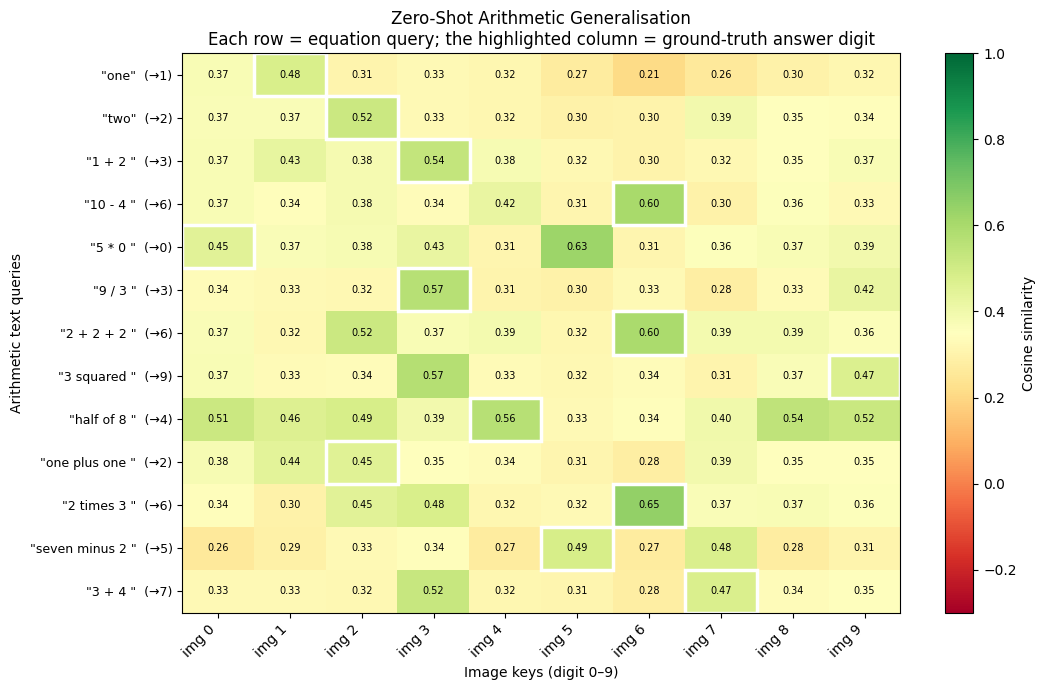

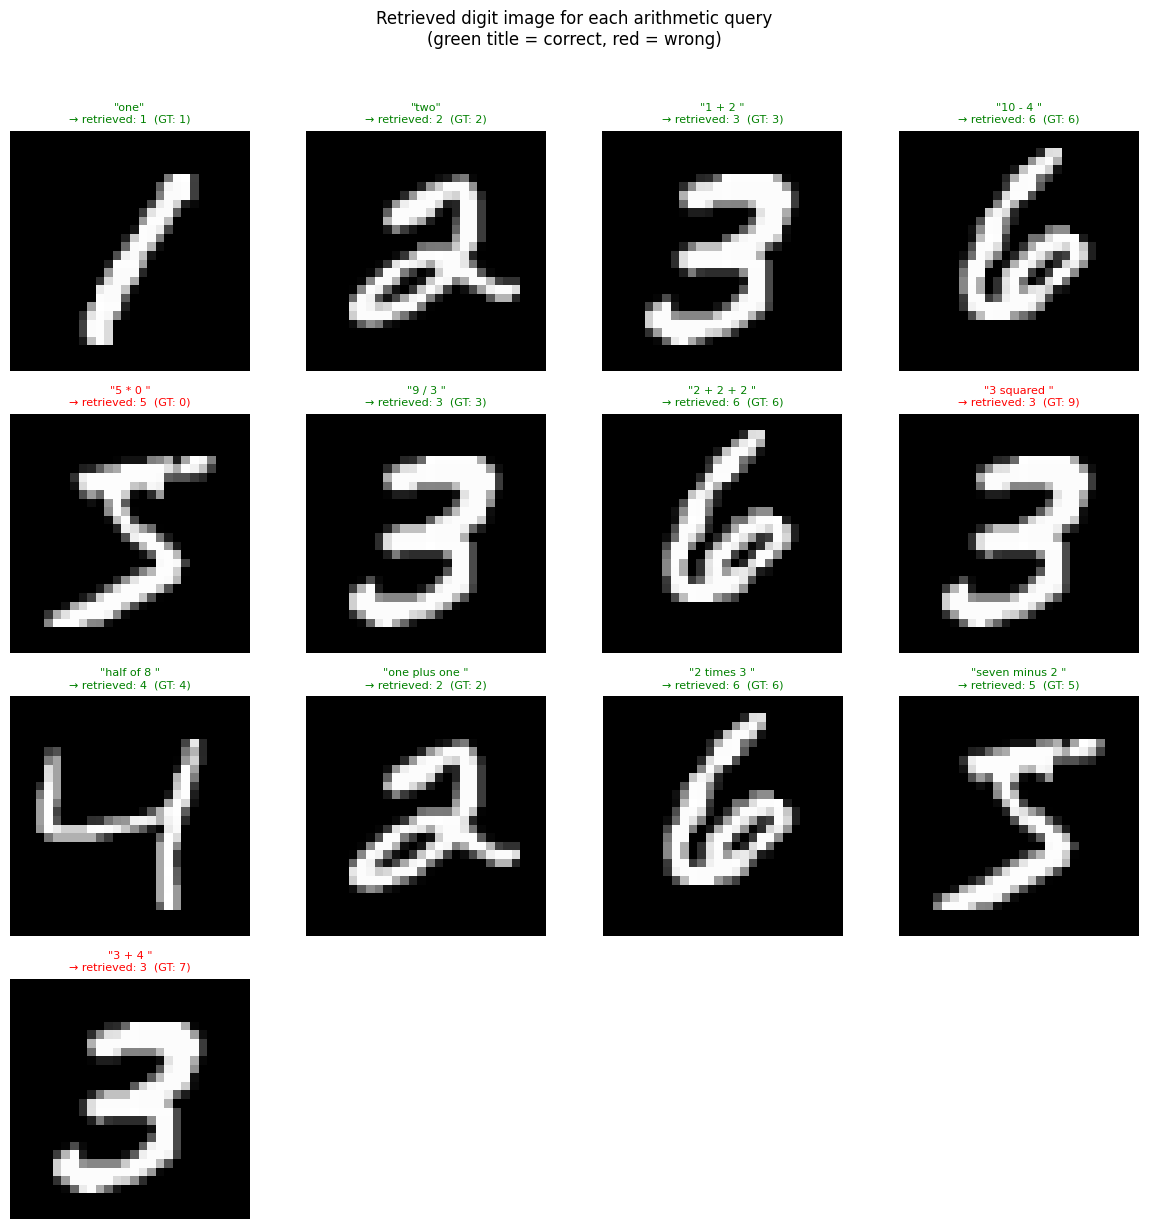

In [25]:
# ── Arithmetic queries and their ground-truth answers (0-9 range) ─────────────
# Deliberately use varied operations and phrasings to stress-test generalisation.
arithmetic_queries = [
    # (query string,  expected digit answer)
    ("one",             1),
    ("two",             2),
    ("1 + 2 ",          3),
    ("10 - 4 ",         6),
    ("5 * 0 ",          0),
    ("9 / 3 ",          3),
    ("2 + 2 + 2 ",      6),
    ("3 squared ",      9),
    ("half of 8 ",      4),
    ("one plus one ",   2),
    ("2 times 3 ",      6),
    ("seven minus 2 ",  5),
    ("3 + 4 ",          7),
]

# ── Encode each arithmetic query as a text-only LLaVA prompt ─────────────────
# We reuse format_text_prompt but override the description string directly.
def format_arbitrary_text(description: str) -> dict:
    """Like format_text_prompt but accepts any string, not just 'The number N'."""
    conversation = [{"role": "user", "content": description}]
    text = processor.tokenizer.apply_chat_template(
        conversation, tokenize=False, add_generation_prompt=True
    )
    inputs = processor.tokenizer(text, return_tensors="pt")
    return {k: v.to(DEVICE) for k, v in inputs.items()}

model.eval()
print("Encoding arithmetic queries ...\n")

query_embeddings = []
with torch.no_grad():
    for q_str, _ in arithmetic_queries:
        emb = get_embedding(format_arbitrary_text(q_str))
        query_embeddings.append(emb)

Q_arith = torch.stack(query_embeddings)   # (num_queries, H)

# K_eval was computed in Section 9 — the 10 image embeddings, index == digit
# Recompute if needed (e.g. kernel was restarted after training):
if "K_eval" not in dir():
    with torch.no_grad():
        K_eval = torch.stack([get_embedding(i) for i in all_image_inputs])

# ── Cosine similarity: each arithmetic query vs all 10 digit images ───────────
sim_arith = (Q_arith @ K_eval.T).cpu().float().numpy()   # (num_queries, 10)

# ── Results table ─────────────────────────────────────────────────────────────
print(f"{'Query':<25}  {'GT':>3}  {'Top-1':>5}  {'Score':>6}  {'✓?':>3}")
print("-" * 55)

correct = 0
for (q_str, gt), row in zip(arithmetic_queries, sim_arith):
    top1_idx   = int(row.argmax())
    top1_score = row[top1_idx]
    gt_score   = row[gt]
    hit        = "✓" if top1_idx == gt else "✗"
    if top1_idx == gt:
        correct += 1
    print(f"{q_str:<25}  {gt:>3}  {top1_idx:>5}  {top1_score:>+.3f}  {hit:>3}   "
          f"(GT score: {gt_score:+.3f})")

print("-" * 55)
print(f"Arithmetic Recall@1: {correct}/{len(arithmetic_queries)} = "
      f"{correct/len(arithmetic_queries)*100:.0f}%\n")

# ── Heatmap: arithmetic queries × digit images ───────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(sim_arith, cmap="RdYlGn", vmin=-0.3, vmax=1.0, aspect="auto")
plt.colorbar(im, ax=ax, label="Cosine similarity")

ax.set_xticks(range(10))
ax.set_xticklabels([f"img {d}" for d in range(10)], rotation=45, ha="right")
ax.set_yticks(range(len(arithmetic_queries)))
ax.set_yticklabels([f"\"{q}\"  (→{gt})" for q, gt in arithmetic_queries], fontsize=9)
ax.set_xlabel("Image keys (digit 0–9)")
ax.set_ylabel("Arithmetic text queries")
ax.set_title(
    "Zero-Shot Arithmetic Generalisation\n"
    "Each row = equation query; the highlighted column = ground-truth answer digit"
)

# Outline the ground-truth column for each row
for row_idx, (_, gt) in enumerate(arithmetic_queries):
    ax.add_patch(plt.Rectangle(
        (gt - 0.5, row_idx - 0.5), 1, 1,
        fill=False, edgecolor="white", linewidth=2.5
    ))

# Annotate cell values
for i in range(len(arithmetic_queries)):
    for j in range(10):
        ax.text(j, i, f"{sim_arith[i, j]:.2f}",
                ha="center", va="center", fontsize=7,
                color="black" if -0.1 < sim_arith[i, j] < 0.75 else "white")

plt.tight_layout()
plt.show()

# ── Visual retrieval: show the top-1 retrieved image for each query ───────────
n_cols = 4
n_rows = -(-len(arithmetic_queries) // n_cols)   # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
axes = axes.flatten()

for idx, ((q_str, gt), row) in enumerate(zip(arithmetic_queries, sim_arith)):
    top1_idx = int(row.argmax())
    ax = axes[idx]
    ax.imshow(repr_images[top1_idx], cmap="gray")
    color = "green" if top1_idx == gt else "red"
    ax.set_title(
        f'"{q_str}"\n→ retrieved: {top1_idx}  (GT: {gt})',
        fontsize=8, color=color
    )
    ax.axis("off")

for ax in axes[len(arithmetic_queries):]:
    ax.axis("off")

plt.suptitle("Retrieved digit image for each arithmetic query\n(green title = correct, red = wrong)", y=1.02)
plt.tight_layout()
plt.show()

In [30]:
# ── Arithmetic queries and their ground-truth answers (0-9 range) ─────────────
# Deliberately use varied operations and phrasings to stress-test generalisation.
arithmetic_queries = []
for i in range(1,10):
    for j in range(1,10):
        if i + j < 10: arithmetic_queries.append((f"{i} + {j}", i + j))
        if i - j >= 0: arithmetic_queries.append((f"{i} - {j}", i - j))
        if i * j < 10: arithmetic_queries.append((f"{i} * {j}", i * j))
        if j != 0: arithmetic_queries.append((f"{i}%{j}", i % j))

# ── Encode each arithmetic query as a text-only LLaVA prompt ─────────────────
# We reuse format_text_prompt but override the description string directly.
def format_arbitrary_text(description: str) -> dict:
    """Like format_text_prompt but accepts any string, not just 'The number N'."""
    conversation = [{"role": "user", "content": description}]
    text = processor.tokenizer.apply_chat_template(
        conversation, tokenize=False, add_generation_prompt=True
    )
    inputs = processor.tokenizer(text, return_tensors="pt")
    return {k: v.to(DEVICE) for k, v in inputs.items()}

model.eval()
print("Encoding arithmetic queries ...\n")

query_embeddings = []
with torch.no_grad():
    for q_str, _ in arithmetic_queries:
        emb = get_embedding(format_arbitrary_text(q_str))
        query_embeddings.append(emb)

Q_arith = torch.stack(query_embeddings)   # (num_queries, H)

# K_eval was computed in Section 9 — the 10 image embeddings, index == digit
# Recompute if needed (e.g. kernel was restarted after training):
if "K_eval" not in dir():
    with torch.no_grad():
        K_eval = torch.stack([get_embedding(i) for i in all_image_inputs])

# ── Cosine similarity: each arithmetic query vs all 10 digit images ───────────
sim_arith = (Q_arith @ K_eval.T).cpu().float().numpy()   # (num_queries, 10)

# ── Results table ─────────────────────────────────────────────────────────────
print(f"{'Query':<25}  {'GT':>3}  {'Top-1':>5}  {'Score':>6}  {'✓?':>3}")
print("-" * 55)

correct = 0
correct_list = []
for (q_str, gt), row in zip(arithmetic_queries, sim_arith):
    top1_idx   = int(row.argmax())
    top1_score = row[top1_idx]
    gt_score   = row[gt]
    hit        = "✓" if top1_idx == gt else "✗"
    if top1_idx == gt:
        correct += 1
        correct_list.append(gt)
    print(f"{q_str:<25}  {gt:>3}  {top1_idx:>5}  {top1_score:>+.3f}  {hit:>3}   "
          f"(GT score: {gt_score:+.3f})")

print("-" * 55)
print(f"Arithmetic Recall@1: {correct}/{len(arithmetic_queries)} = "
      f"{correct/len(arithmetic_queries)*100:.0f}%\n")


Encoding arithmetic queries ...

Query                       GT  Top-1   Score   ✓?
-------------------------------------------------------
1 + 1                        2      2  +0.496    ✓   (GT score: +0.496)
1 - 1                        0      1  +0.480    ✗   (GT score: +0.370)
1 * 1                        1      1  +0.523    ✓   (GT score: +0.523)
1%1                          0      1  +0.488    ✗   (GT score: +0.379)
1 + 2                        3      3  +0.535    ✓   (GT score: +0.535)
1 * 2                        2      2  +0.597    ✓   (GT score: +0.597)
1%2                          1      2  +0.435    ✗   (GT score: +0.402)
1 + 3                        4      4  +0.553    ✓   (GT score: +0.553)
1 * 3                        3      3  +0.634    ✓   (GT score: +0.634)
1%3                          1      3  +0.444    ✗   (GT score: +0.428)
1 + 4                        5      5  +0.530    ✓   (GT score: +0.530)
1 * 4                        4      4  +0.668    ✓   (GT score: +0.6

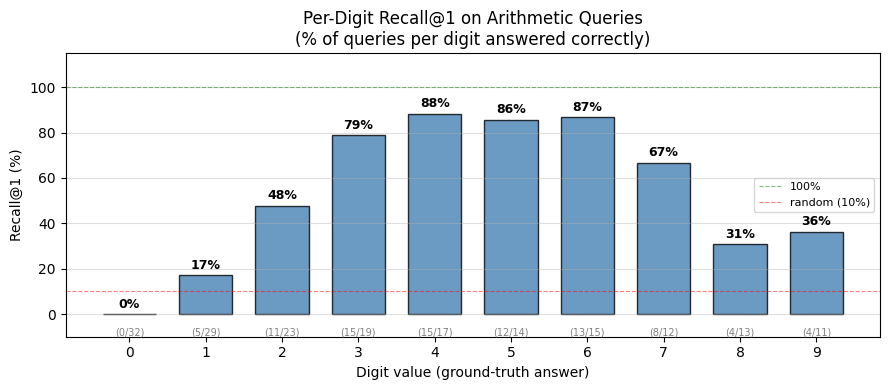

Overall arithmetic Recall@1: 87/185 = 47.0%


In [37]:
# Plot the per-digit accuracy (%) in arithmetic queries
# For each digit d: accuracy = correct_count[d] / total_queries_with_answer_d * 100
digits = list(range(10))

amount_of_digits = {d: 0 for d in digits}
for _, gt in arithmetic_queries:
    amount_of_digits[gt] += 1

# Count correctly predicted queries per digit
correct_per_digit = {d: 0 for d in digits}
for d in correct_list:
    correct_per_digit[d] += 1

# Accuracy per digit (avoid division by zero for digits with no queries)
accuracy_per_digit = [
    correct_per_digit[d] / amount_of_digits[d] * 100 if amount_of_digits[d] > 0 else 0.0
    for d in digits
]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(digits, accuracy_per_digit, width=0.7, alpha=0.8, color="steelblue", edgecolor="black")

# Annotate each bar with its percentage and the query count underneath
for d, bar, acc in zip(digits, bars, accuracy_per_digit):
    n_total = amount_of_digits[d]
    n_ok    = correct_per_digit[d]
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f"{acc:.0f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.text(bar.get_x() + bar.get_width() / 2, -6,
            f"({n_ok}/{n_total})", ha="center", va="top", fontsize=7, color="gray")

ax.set_xticks(digits)
ax.set_xlabel("Digit value (ground-truth answer)")
ax.set_ylabel("Recall@1 (%)")
ax.set_ylim(-10, 115)
ax.set_title("Per-Digit Recall@1 on Arithmetic Queries\n(% of queries per digit answered correctly)")
ax.axhline(y=100, color="green", linestyle="--", linewidth=0.8, alpha=0.5, label="100%")
ax.axhline(y=10,  color="red",   linestyle="--", linewidth=0.8, alpha=0.5, label="random (10%)")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

overall_acc = sum(correct_per_digit.values()) / sum(amount_of_digits.values()) * 100
print(f"Overall arithmetic Recall@1: {sum(correct_per_digit.values())}/{sum(amount_of_digits.values())} = {overall_acc:.1f}%")

## Summary & Key Takeaways

| Component | Choice | Rationale |
|-----------|--------|-----------|
| Base model | `llava-hf/llava-v1.6-mistral-7b-hf` | Small yet capable LLaVA variant |
| Quantisation | 4-bit NF4 (`bitsandbytes`) | Compresses 14 GB → ~4 GB, fits T4 16 GB |
| Compute dtype | `bfloat16` | Larger dynamic range than float16, avoids inf/NaN in deep activations |
| Adaptation | LoRA r=8, α=16, all-linear | <1% trainable params, adapts both vision + LLM |
| kbit training | `prepare_model_for_kbit_training` | Required for stable LoRA gradients over 4-bit base |
| Embedding | Last-token hidden state | Full context summary (VLM2Vec insight) |
| Loss | Symmetric diagonal InfoNCE, τ=0.07 | Proven effective in CLIP and follow-ups |
| Corpus | 10 MNIST images, 10 text descriptions | Minimal reproducible proof-of-concept |